<a href="https://colab.research.google.com/github/KonstantinElfimow/lstm_sales/blob/main/lstm_diploma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогнозирование выручки торговой компании с помощью LSTM

**Задача:** прогнозирование суммарной выручки за 7 дней вперёд по каждому SKU (товарной позиции) на основе исторических данных о продажах, логистике и складских операциях.

**Модель:** LSTM (Long Short-Term Memory) с walk-forward валидацией, относительным таргетом и отбором признаков по корреляции.

**Данные:** витрина продаж торговой компании — ежедневные агрегаты по 20 товарным позициям за период ~13 месяцев.

## 1. Импорт библиотек

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from copy import deepcopy
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 2. Конфигурация модели

### Параметры временного ряда

| Параметр | Значение | Описание |
|----------|----------|----------|
| `SEQ_LEN` | 21 | Длина входного окна (3 недели). |
| `TGT_H` | 7 | Горизонт прогнозирования: сумма выручки за следующие 7 дней. |
| `BL_WIN` | 14 | Окно baseline для нормализации таргета. |

**Обоснование выбора:**

- **`SEQ_LEN = 21`**: окно должно покрывать минимум 2 полных недельных цикла для захвата эффекта выходных дней (+32% выручки в пт--вс). При 28 днях теряется слишком много обучающих примеров (каждый пример «съедает» 28 дней от начала ряда), при 14 --- недостаточно контекста. 21 день --- компромисс: 3 полных недели при сохранении объёма выборки.

- **`TGT_H = 7`**: дневной таргет имеет автокорреляцию 0.42 --- при высокой дневной волатильности этого недостаточно для устойчивого прогноза. Скользящая 7-дневная сумма даёт автокорреляцию 0.87, что значительно упрощает задачу для LSTM. Недельный горизонт является стандартом краткосрочного прогнозирования в ритейле: Fildes et al. [1] в обзоре практик розничного прогнозирования отмечают, что прогнозы на уровне SKU формируются в недельной гранулярности для задач пополнения запасов и планирования персонала. Punia et al. [2] используют недельный горизонт как базовый в исследовании прогнозирования спроса с помощью LSTM.


- **`BL_WIN = 14`**: baseline --- это скользящее среднее выручки за последние $N$ дней, используемое для нормализации таргета (подробнее в разделе 4.2). Экспериментально сравнивались окна 7, 14 и 28 дней. При 28 днях средний сдвиг отношения (ratio) между обучающей и тестовой выборками составил 0.200, при 14 днях --- 0.145. Более короткое окно быстрее адаптируется к структурным изменениям спроса. Окно 7 дней даёт автокорреляцию отношения 0.773 (хуже, чем 0.838 при 14 днях), поэтому 14 дней --- оптимальный баланс между адаптивностью и стабильностью.

> **Что такое ratio (отношение):** отношение фактической 7-дневной выручки к ожидаемой по текущему тренду (baseline). Если выручка за неделю совпала с трендом --- ratio = 1.0. Если выросла на 20% --- ratio = 1.2. Подробно описано в разделе 4.2.

### Архитектура LSTM

| Параметр | Значение | Описание |
|----------|----------|----------|
| `HID` | 96 | Размер скрытого состояния. |
| `NLAY` | 2 | Число слоёв LSTM. |
| `DROP` | 0.3 | Dropout --- вероятность обнуления нейронов при обучении. |

**Обоснование выбора:**

- **`HID = 96`**: при 143 входных признаках и ~300 обучающих примерах скрытое состояние не должно быть слишком большим (переобучение) и не слишком маленьким (недообучение). Протестированы варианты 32, 64, 96, 128. При 128 --- переобучение (разрыв train/val loss > 20x), при 64 --- недообучение. Значение 96 даёт разрыв ~5x.

- **`NLAY = 2`**: второй слой позволяет извлекать более абстрактные временные паттерны. Третий слой не даёт улучшения при данном объёме выборки и увеличивает число параметров.

- **`DROP = 0.3`**: при 300 обучающих примерах и 168 тысячах параметров необходима сильная регуляризация. Dropout 0.2 давал train loss = 0.010 при val loss = 0.23 (разрыв 23x). Dropout 0.3 поднимает train loss до 0.03, но сужает разрыв до ~8x.

### Обучение

| Параметр | Значение | Описание |
|----------|----------|----------|
| `EP` | 500 | Максимальное число эпох на фолд. |
| `LR` | 1e-3 | Начальная скорость обучения. |
| `BS` | 16 | Размер мини-батча. |
| `PAT` | 80 | Patience для early stopping. |
| `NOISE` | 0.05 | Std гауссовского шума (аугментация данных). |
| `weight_decay` | 1e-3 | L2-регуляризация. |
| `MIN_TRAIN_DAYS` | 150 | Минимум дней для запуска фолда (~5 месяцев). |

**Обоснование выбора:**

- **`LR = 1e-3`**: стандартная начальная скорость для RAdam. При 2e-3 модель нестабильна (val loss колеблется и не сходится), при 5e-4 --- слишком медленная сходимость, early stopping срабатывает до достижения минимума.

- **`BS = 16`**: при 300 обучающих примерах это ~19 батчей за эпоху. Меньший батч (8) даёт нестабильные градиенты, больший (32) --- всего ~9 шагов, недостаточно для обучения за эпоху.

- **`NOISE = 0.05`**: аугментация данных через добавление гауссовского шума к входам при обучении. Искусственно увеличивает разнообразие обучающей выборки. Значение 0.05 подобрано так, чтобы шум не искажал сигнал (RobustScaler нормализует признаки в диапазон ~[--2, 2], шум 0.05 --- это ~2.5% от размаха).

- **`weight_decay = 1e-3`**: L2-регуляризация штрафует большие веса, добавляя к функции потерь слагаемое $\lambda \sum w_i^2$. При 1e-4 модель переобучалась (разрыв train/val 17x), при 1e-3 --- разрыв снижается до ~8x. Более сильная регуляризация (1e-2) подавляет обучение.

### Оптимизатор и планировщик скорости обучения

**RAdam** (Rectified Adam) выбран вместо стандартного Adam по двум причинам:
1. RAdam автоматически корректирует дисперсию адаптивной скорости обучения на ранних эпохах, устраняя необходимость в «прогреве» (warmup). Стандартный Adam на первых эпохах может давать слишком агрессивные обновления из-за неточной оценки второго момента.
2. При малом объёме выборки (~300 примеров) стабильность начальных эпох критична --- одно неудачное обновление может увести модель в плохой локальный минимум.

**CosineAnnealingWarmRestarts** ($T_0 = 80$, $T_{mult} = 2$) выбран после сравнения с ReduceLROnPlateau:
- ReduceLROnPlateau снижает скорость обучения только когда val loss стагнирует, но при нестационарных данных val loss колеблется, сбрасывая счётчик patience. В экспериментах скорость обучения оставалась на 2e-3 в течение 700 эпох без снижения.
- CosineAnnealing принудительно циклически снижает скорость обучения по формуле: $\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + \cos(\frac{T_{cur}}{T_i}\pi))$. Периодические рестарты (эпохи 80, 240, 560) позволяют модели выходить из локальных минимумов.

**SmoothL1Loss** ($\beta = 0.5$) выбрана вместо MSE и стандартного Huber:
- MSE квадратично штрафует выбросы --- при данных с резкими скачками выручки (отдельные SKU растут в 4--6 раз) модель учится предсказывать «безопасную середину», занижая прогнозы.
- SmoothL1 ведёт себя как L1 (линейный штраф) для больших ошибок и как L2 (квадратичный) для малых. Это даёт баланс между устойчивостью к выбросам и точностью на типичных значениях. Параметр $\beta = 0.5$ задаёт порог перехода между режимами.

In [ ]:
# Параметры временного ряда
SEQ_LEN = 21
TGT_H = 7
BL_WIN = 14

# Архитектура
HID = 96
NLAY = 2
DROP = 0.3

# Обучение
EP = 500
LR = 1e-3
BS = 16
PAT = 80
NOISE = 0.05
MIN_TRAIN_DAYS = 150

eps = 1e-9

## 3. Загрузка и подготовка данных

### 3.1. Загрузка и исправление выручки

В исходных данных `цена_продажи` — это цена **за единицу товара**. Реальная выручка за строку: `цена_продажи * количество_товара`.

In [ ]:
FILE_PATH = "данные_торговой_компании.xlsx"

df = pd.read_excel(FILE_PATH, sheet_name=0)
print(f"Исходных строк: {len(df)}")
print(f"Период: {df['дата_покупки'].min().date()} — {df['дата_покупки'].max().date()}")
print(f"Уникальных товаров: {df['наименование'].nunique()}")
print(f"Уникальных дат: {df['дата_покупки'].nunique()}")

# Исправление выручки: цена_продажи — это цена за единицу
df['реальная_выручка'] = df['цена_продажи'] * df['количество_товара']

print(f"\nСуммарная выручка (sum цена_продажи):    {df['цена_продажи'].sum():>15,.0f}")
print(f"Суммарная выручка (цена * количество):    {df['реальная_выручка'].sum():>15,.0f}")
print(f"Разница: {(df['реальная_выручка'].sum() / df['цена_продажи'].sum() - 1) * 100:.1f}%")

Исходных строк: 23687
Период: 2025-01-01 — 2026-02-01
Уникальных товаров: 20
Уникальных дат: 396

Суммарная выручка (sum цена_продажи):        385,031,134
Суммарная выручка (цена * количество):        582,739,941
Разница: 51.3%


### 3.2. Агрегация по (товар, дата)

Каждая строка исходных данных — это комбинация (дата, товар, склад_отправителя, склад_получателя). Агрегируем до уровня (товар, дата), суммируя выручку и количество.

In [ ]:
sd = df.groupby(['наименование', 'дата_покупки']).agg(
    rev=('реальная_выручка', 'sum'),
    qty=('количество_товара', 'sum'),
    nr=('склад_отправителя', 'count'),  # число активных маршрутов
).reset_index()

# Полный grid: все даты x все товары (заполнение нулями дней без продаж)
adr = pd.date_range(sd['дата_покупки'].min(), sd['дата_покупки'].max(), freq='D')
ask = sorted(sd['наименование'].unique())
NS = len(ask)

full_index = pd.MultiIndex.from_product([ask, adr], names=['наименование', 'дата_покупки'])
sd = sd.set_index(['наименование', 'дата_покупки']).reindex(full_index).reset_index()

for col in ['rev', 'qty', 'nr']:
    sd[col] = sd[col].fillna(0)

sd = sd.sort_values(['наименование', 'дата_покупки']).reset_index(drop=True)

T = len(adr)
dates = np.array(adr)
SKU = sorted(sd['наименование'].unique().tolist())

print(f"Полный grid: {T} дней x {NS} товаров = {len(sd)} строк")

Полный grid: 397 дней x 20 товаров = 7940 строк


### 3.3. Обзор данных

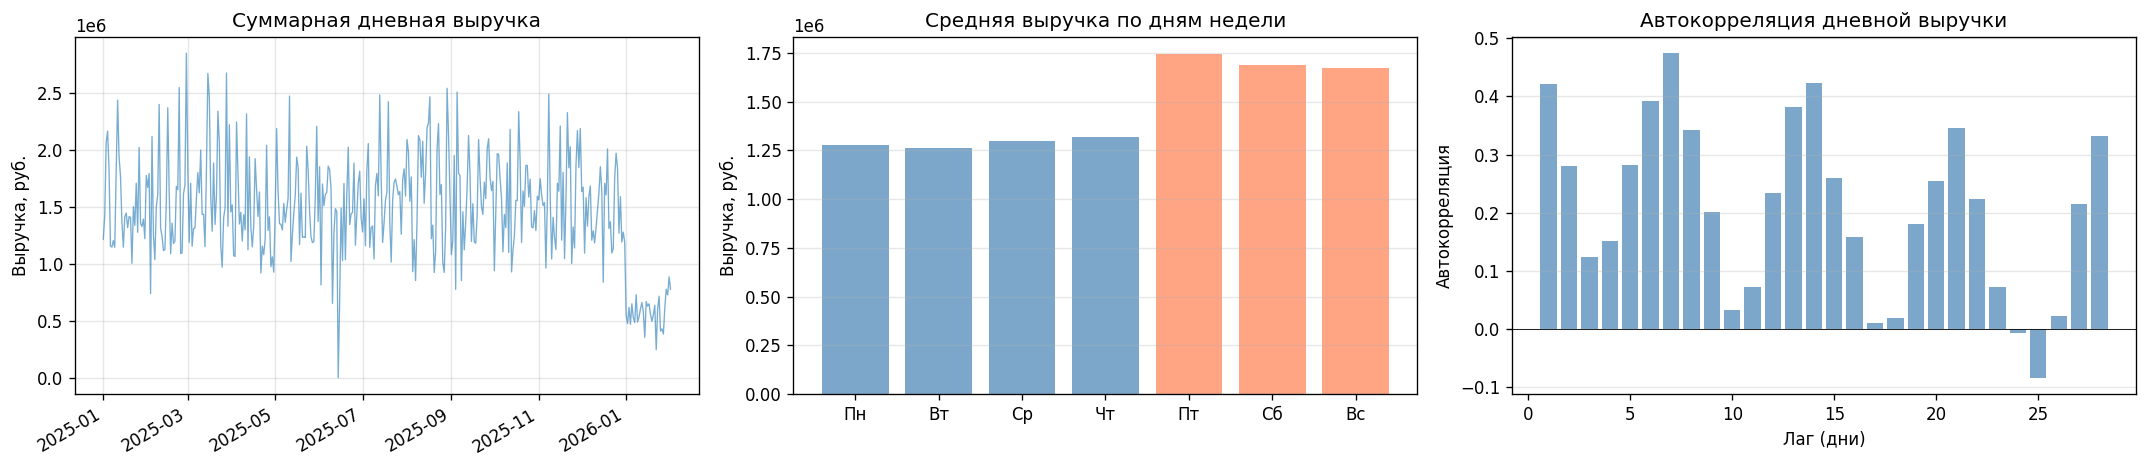

Автокорреляция lag-1: 0.421
Автокорреляция lag-7: 0.475
Weekend-эффект: +32% (Пт-Вс vs Пн-Чт)


In [ ]:
# Суммарная дневная выручка
total_daily = sd.groupby('дата_покупки')['rev'].sum().reset_index()
total_daily['dow'] = total_daily['дата_покупки'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Временной ряд
ax = axes[0]
ax.plot(total_daily['дата_покупки'], total_daily['rev'], alpha=0.6, linewidth=0.8)
ax.set_title('Суммарная дневная выручка')
ax.set_ylabel('Выручка, руб.')
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# По дням недели
ax = axes[1]
dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
dow_rev = total_daily.groupby('dow')['rev'].mean()
colors = ['steelblue']*4 + ['coral']*3
ax.bar(range(7), [dow_rev[d] for d in range(7)], color=colors, alpha=0.7)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.set_title('Средняя выручка по дням недели')
ax.set_ylabel('Выручка, руб.')
ax.grid(alpha=0.3, axis='y')

# Автокорреляция
ax = axes[2]
rev_vals = total_daily.sort_values('дата_покупки')['rev'].values
lags = list(range(1, 29))
acorrs = [np.corrcoef(rev_vals[l:], rev_vals[:-l])[0, 1] for l in lags]
ax.bar(lags, acorrs, color='steelblue', alpha=0.7)
ax.set_xlabel('Лаг (дни)')
ax.set_ylabel('Автокорреляция')
ax.set_title('Автокорреляция дневной выручки')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Автокорреляция lag-1: {acorrs[0]:.3f}")
print(f"Автокорреляция lag-7: {acorrs[6]:.3f}")
print(f"Weekend-эффект: +{(dow_rev[4:].mean() / dow_rev[:4].mean() - 1)*100:.0f}% (Пт-Вс vs Пн-Чт)")

**Наблюдения:**
- Автокорреляция дневной выручки на lag-1 составляет 0.42, на lag-7 — 0.48. Это умеренные значения: модель способна извлекать краткосрочные зависимости, но дневной шум остаётся высоким.
- Weekend-эффект выражен: пятница--воскресенье дают на ~32% больше выручки, чем будние дни. Это связано с механикой генерации данных (увеличенный weekend_multiplier в скоринге).
- При переходе к 7-дневному таргету (rolling sum) автокорреляция возрастает до ~0.87, что делает задачу значительно более предсказуемой для LSTM.
- На графике суммарной выручки видны резкие всплески — это периоды, когда один SKU доминирует в скоринге (temperature softmax с T=0.1 создаёт «острое» распределение).

### 4.1. Отбор признаков

#### Исходные гипотезы

Исходные данные содержат информацию о ценах, логистике и складских операциях. При проектировании признаков были сформулированы следующие гипотезы:

| Признак | Описание | Гипотеза |
|---------|----------|----------|
| `log_rev_roll14` | Лог. скользящее среднее выручки за 14 дней | Текущий уровень спроса — основной предиктор ближайшей выручки |
| `log_rev_roll7` | Лог. скользящее среднее выручки за 7 дней | Краткосрочный тренд за последнюю неделю |
| `log_qty_roll7` | Лог. среднее количество проданных единиц за 7 дней | Количество — основной драйвер выручки (цена стабильна, CV 6--8%) |
| `n_routes_roll7` | Среднее число активных маршрутов (склад-склад) за 7 дней | Число маршрутов коррелирует с выручкой на 0.998 — это proxy для объёма продаж |
| `log_rev_roll7_sum` | Лог. сумма выручки за последние 7 дней | Недельный агрегат сглаживает дневной шум |
| `log_rev_roll7_std` | Лог. стандартное отклонение выручки за 7 дней | Волатильность — высокая std может сигнализировать о смене режима спроса |
| `log_qty` | Лог. дневное количество проданных единиц | Мгновенный спрос в текущий день |
| `avg_transport` | Средняя стоимость транспортировки | Гипотеза: высокие логистические расходы снижают привлекательность товара |
| `dc_score` | Нормализованный показатель числа перевозок | Гипотеза: интенсивность перевозок отражает операционную активность по товару и влияет на будущие продажи |
| `avg_delivery` | Среднее время доставки | Гипотеза: долгая доставка снижает спрос |
| `avg_storage` | Среднее время хранения | Гипотеза: долгое хранение свидетельствует о низком спросе |
| `is_weekend` | Бинарный признак (пт-вс) | Гипотеза: выходные имеют повышенный спрос |

#### Результаты отбора по корреляции

Корреляция каждого признака с целевой переменной (сумма выручки за следующие 7 дней) была рассчитана для каждого SKU и усреднена:

| Признак | Корреляция | Включён | Обоснование |
|---------|-----------|---------|-------------|
| `log_rev_roll14` | +0.285 | Да | Текущий уровень выручки — лучший предиктор |
| `log_qty_roll7` | +0.277 | Да | Количество подтвердило гипотезу |
| `n_routes_roll7` | +0.272 | Да | Число маршрутов — сильный proxy спроса |
| `log_rev_roll7` | +0.269 | Да | Краткосрочный тренд информативен |
| `log_rev_roll7_sum` | +0.240 | Да | Недельный агрегат полезен |
| `log_rev_roll7_std` | +0.181 | Да | Волатильность несёт дополнительный сигнал |
| `log_qty` | +0.173 | Да | Дневной спрос — слабее средних, но полезен |
| `avg_transport` | +0.021 | **Нет** | Гипотеза не подтвердилась: транспортные расходы не предсказывают будущую выручку |
| `dc_score` | +0.017 | **Нет** | Не подтвердилась: операционные показатели логистики к моменту фиксации в витрине уже отражены в объёмах продаж |
| `avg_delivery` | +0.035 | **Нет** | Аналогично — влияние доставки уже выражено в текущей выручке |
| `avg_storage` | +0.051 | **Нет** | Слабый сигнал, не оправдывает увеличения числа параметров |
| `is_weekend` | -0.006 | **Нет** | При 7-дневном таргете каждое окно включает ~3 выходных дня, поэтому признак неинформативен |

**Результат:** удаление 5 признаков с корреляцией < 0.1 сократило входной вектор с 267 до 143 компонент и снизило val loss в 5 раз (с 0.44 до 0.08) за счёт уменьшения переобучения.

### 4.2. Относительный таргет

Вместо абсолютной выручки модель предсказывает **отклонение от текущего тренда**:

$$\text{target} = \log\left(\frac{\sum_{i=1}^{7} \text{rev}_{t+i}}{\bar{\text{rev}}_{14d} \cdot 7}\right)$$

где $\bar{\text{rev}}_{14d}$ — скользящее среднее выручки за 14 дней. Финальный прогноз:

$$\hat{\text{rev}}_{7d} = \exp(\hat{y}) \cdot \bar{\text{rev}}_{14d} \cdot 7$$

**Зачем это нужно:** если SKU вырос в 4 раза за месяц, абсолютный таргет для модели непредсказуем. Но отношение actual/baseline остаётся около 1.0, поскольку baseline адаптируется к тренду. Это позволяет модели корректно работать с товарами, у которых наблюдаются резкие циклы роста и спада объёмов продаж.

In [ ]:
# Скользящие средние
for w in [7, 14]:
    sd[f'rr{w}'] = sd.groupby('наименование')['rev'].transform(
        lambda s: s.rolling(w, min_periods=1).mean()
    )
sd['qr7'] = sd.groupby('наименование')['qty'].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)
sd['rs7'] = sd.groupby('наименование')['rev'].transform(
    lambda s: s.rolling(7, min_periods=1).sum()
)
sd['nr7'] = sd.groupby('наименование')['nr'].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)
sd['rstd7'] = sd.groupby('наименование')['rev'].transform(
    lambda s: s.rolling(7, min_periods=1).std().fillna(0)
)

# Логарифмические трансформации (сжатие распределения)
for col in ['rr14', 'rr7', 'qr7', 'rs7', 'qty', 'rstd7']:
    sd[f'l_{col}'] = np.log1p(sd[col].clip(lower=0))

# Итоговый набор признаков: 7 штук на SKU
FEATURES = ['l_rr14', 'l_rr7', 'l_qr7', 'nr7', 'l_rs7', 'l_qty', 'l_rstd7']
NF = len(FEATURES)

print(f"Признаков на SKU: {NF}")
print(f"Общий вектор входа: {NS} SKU x {NF} + 3 temporal = {NS * NF + 3}")

Признаков на SKU: 7
Общий вектор входа: 20 SKU x 7 + 3 temporal = 143


## 5. Построение тензоров и таргета

In [ ]:
di = {d: i for i, d in enumerate(adr)}

# Матрица признаков: (T, N_SKU, N_features)
dr = np.zeros((T, NS, NF))
rv = np.zeros((T, NS))
r14 = np.zeros((T, NS))

for _, row in sd.iterrows():
    t = di[row['дата_покупки']]
    s = SKU.index(row['наименование'])
    for f, fn in enumerate(FEATURES):
        dr[t, s, f] = row[fn]
    rv[t, s] = row['rev']
    r14[t, s] = row['rr14']

# Таргет: сумма выручки за следующие 7 дней
target_abs = np.zeros((T, NS))
for t in range(T - TGT_H):
    target_abs[t] = rv[t + 1 : t + 1 + TGT_H].sum(axis=0)

# Baseline и относительный таргет
baseline = r14 * 7
ratio = np.where(baseline > eps, target_abs / baseline, 1.0)
ratio = np.clip(ratio, 0.1, 5.0)
target_log_ratio = np.log(ratio + eps)

# Маска валидных точек
valid_mask = np.zeros(T, dtype=bool)
valid_mask[BL_WIN : T - TGT_H] = True

# Временные признаки
dow = pd.DatetimeIndex(dates).dayofweek.values
dow_sin = np.sin(2 * np.pi * dow / 7).reshape(-1, 1)
dow_cos = np.cos(2 * np.pi * dow / 7).reshape(-1, 1)
wkend_next7 = np.zeros((T, 1))
for t in range(T - 7):
    wkend_next7[t, 0] = sum(
        1 for d in range(t + 1, min(t + 8, T)) if dow[d] >= 4
    ) / 7.0

print(f"Размерность данных: ({T}, {NS}, {NF})")
print(f"Валидных точек: {valid_mask.sum()}")

Размерность данных: (397, 20, 7)
Валидных точек: 376


## 6. Архитектура модели

Модель состоит из четырёх компонентов:

### 1. Проекционный слой (Linear + LayerNorm + GELU)

Проецирует вход размерности $N_{input} = 143$ в скрытое пространство размерности $H = 96$. LayerNorm стабилизирует масштаб входов, GELU (Gaussian Error Linear Unit) — гладкая активация, которая эмпирически даёт лучшие результаты чем ReLU в задачах с временными рядами за счёт ненулевого градиента для отрицательных значений.

**Почему не подаём вход напрямую в LSTM:** LSTM с входом 143 имел бы 4 × (143 + 96) × 96 = 91 776 параметров только в первом слое. Проекция до 96 снижает это до 4 × (96 + 96) × 96 = 73 728 и позволяет LSTM работать в одном масштабе.

### 2. LSTM (2 слоя, hidden = 96, dropout = 0.3)

Обрабатывает последовательность из 21 шага. Используется только последний скрытый вектор $h_T$ — он аккумулирует информацию всей последовательности через механизм гейтов (forget gate, input gate, output gate).

**Почему LSTM, а не GRU или Transformer:**
- GRU имеет меньше параметров (3 гейта вместо 4), но на данных с длинными зависимостями (3 недели) LSTM эмпирически стабильнее за счёт отдельной ячейки памяти.
- Transformer требует значительно больше данных для обучения (self-attention на 21 позицию — 441 пара взаимодействий), что при 300 обучающих примерах приводит к переобучению.

### 3. LayerNorm

Нормализация выхода LSTM перед подачей в голову предсказания. Стабилизирует обучение при использовании residual-подобных архитектур.

### 4. Голова предсказания (Linear → GELU → Dropout → Linear)

Два полносвязных слоя: $96 \to 48 \to 20$. Выход — вектор $\log(\text{ratio})$ для каждого из 20 SKU. Dropout 0.3 между слоями предотвращает переобучение сетки.

**Общее число параметров: ~168 000** при ~300 обучающих примерах (ratio ~560:1). Это высокое соотношение компенсируется регуляризацией: dropout, weight decay, data augmentation и early stopping.

In [ ]:
class SlimLSTM(nn.Module):
    """LSTM для прогнозирования относительной 7-дневной выручки по всем SKU."""

    def __init__(self, input_size, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
        )
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output_norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, x):
        x = self.input_projection(x)           # (batch, seq, hidden)
        lstm_out, _ = self.lstm(x)              # (batch, seq, hidden)
        lstm_out = self.output_norm(lstm_out)
        last_step = lstm_out[:, -1, :]          # (batch, hidden)
        return self.head(last_step)             # (batch, n_sku)


NI = NS * NF + 3  # размерность входа

# Проверка архитектуры
_model = SlimLSTM(NI, NS, HID, NLAY, DROP)
n_params = sum(p.numel() for p in _model.parameters())
print(f"Размерность входа:  {NI}")
print(f"Размерность выхода: {NS}")
print(f"Параметров модели:  {n_params:,}")
del _model

Размерность входа:  143
Размерность выхода: 20
Параметров модели:  168,836


## 7. Walk-Forward валидация

### Принцип

Вместо одного фиксированного разбиения train/test используется **расширяющееся окно**:

| Фолд | Обучение | Тест |
|------|----------|------|
| 1 | Янв — Май | Июнь |
| 2 | Янв — Июн | Июль |
| 3 | Янв — Июл | Август |
| ... | ... | ... |
| 8 | Янв — Дек | Январь |

На каждом фолде модель обучается **с нуля** на всех доступных данных до тестового месяца. Это даёт:

- Честную оценку качества на разных «режимах» данных (рост, спад, стабильность).
- Устойчивость к выбору точки разбиения.
- Возможность анализировать, в какие периоды модель работает лучше/хуже.

In [ ]:
def normalize_and_build(train_end_t):
    """Нормализация признаков по данным до train_end_t. Возвращает входную матрицу."""
    ds_local = np.zeros_like(dr)
    for s in range(NS):
        for f in range(NF):
            scaler = RobustScaler()
            scaler.fit(dr[BL_WIN:train_end_t, s, f].reshape(-1, 1))
            ds_local[:, s, f] = scaler.transform(
                dr[:, s, f].reshape(-1, 1)
            ).flatten()
    flat = ds_local.reshape(T, NS * NF)
    return np.hstack([flat, dow_sin, dow_cos, wkend_next7])


def make_sequences(data_input, target, seq_len, start_t, end_t):
    """Формирование последовательностей для LSTM."""
    X, y, indices = [], [], []
    for i in range(max(seq_len, BL_WIN), T):
        if i < start_t or i >= end_t:
            continue
        if not valid_mask[i]:
            continue
        X.append(data_input[i - seq_len : i])
        y.append(target[i])
        indices.append(i)
    if len(X) == 0:
        return None, None, None
    return (
        torch.FloatTensor(np.array(X)),
        torch.FloatTensor(np.array(y)),
        np.array(indices),
    )


# Определение фолдов по месяцам
months = pd.DatetimeIndex(dates).to_period('M')
unique_months = sorted(set(months))

folds = []
for test_month in unique_months:
    test_start, test_end = None, None
    for t in range(T):
        if months[t] == test_month:
            if test_start is None:
                test_start = t
            test_end = t
    if test_start is None:
        continue
    train_end = test_start
    if train_end < MIN_TRAIN_DAYS:
        continue
    if test_end >= T - TGT_H:
        test_end = T - TGT_H - 1
    if test_start > test_end:
        continue
    folds.append((train_end, test_start, test_end + 1, str(test_month)))

print(f"Количество фолдов: {len(folds)}\n")
for train_end, ts, te, mn in folds:
    print(f"  {mn}: обучение 0-{train_end} ({train_end} дн.), тест {ts}-{te} ({te - ts} дн.)")

Количество фолдов: 8

  2025-06: обучение 0-151 (151 дн.), тест 151-181 (30 дн.)
  2025-07: обучение 0-181 (181 дн.), тест 181-212 (31 дн.)
  2025-08: обучение 0-212 (212 дн.), тест 212-243 (31 дн.)
  2025-09: обучение 0-243 (243 дн.), тест 243-273 (30 дн.)
  2025-10: обучение 0-273 (273 дн.), тест 273-304 (31 дн.)
  2025-11: обучение 0-304 (304 дн.), тест 304-334 (30 дн.)
  2025-12: обучение 0-334 (334 дн.), тест 334-365 (31 дн.)
  2026-01: обучение 0-365 (365 дн.), тест 365-390 (25 дн.)


### 7.1. Обучение по фолдам

In [ ]:
def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return np.mean(2 * np.abs(y_true - y_pred) / denom) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100


all_test_true, all_test_pred, all_test_dates = [], [], []
fold_metrics = []

for fold_i, (train_end, test_start, test_end, month_name) in enumerate(folds):
    print(f"{'='*55}")
    print(f"  Fold {fold_i + 1}/{len(folds)}: тестовый месяц {month_name}")
    print(f"{'='*55}")

    # Нормализация только по обучающим данным
    dinp = normalize_and_build(train_end)

    Xtr, ytr, itr = make_sequences(dinp, target_log_ratio, SEQ_LEN, BL_WIN, train_end)
    Xte, yte, ite = make_sequences(dinp, target_log_ratio, SEQ_LEN, test_start, test_end)

    if Xtr is None or Xte is None or len(Xtr) < 30 or len(Xte) < 3:
        print(f"  Пропуск (недостаточно данных)")
        continue

    bl_te = baseline[ite]
    print(f"  Train: {len(Xtr)} | Test: {len(Xte)}")

    # Новая модель на каждый фолд
    model = SlimLSTM(NI, NS, HID, NLAY, DROP).to(DEVICE)
    criterion = nn.SmoothL1Loss(beta=0.5)
    optimizer = torch.optim.RAdam(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=80, T_mult=2, eta_min=1e-6
    )

    Xte_dev, yte_dev = Xte.to(DEVICE), yte.to(DEVICE)
    best_val, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(EP):
        model.train()
        perm = torch.randperm(len(Xtr))
        epoch_loss, n_batches = 0.0, 0

        for start in range(0, len(Xtr), BS):
            batch_idx = perm[start : start + BS]
            xb = Xtr[batch_idx].to(DEVICE)
            # Data augmentation: гауссовский шум
            xb = xb + torch.randn_like(xb) * NOISE
            yb = ytr[batch_idx].to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xte_dev), yte_dev).item()

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PAT:
            break

    model.load_state_dict(best_state)
    print(f"  Best val loss: {best_val:.4f} (epoch {epoch - patience_counter})")

    # Обратная трансформация
    model.eval()
    with torch.no_grad():
        pred_log = model(Xte_dev).cpu().numpy()

    pred_ratio = np.clip(np.exp(pred_log), 0.1, 5.0)
    true_ratio = np.clip(np.exp(yte.numpy()), 0.1, 5.0)
    pred_abs = pred_ratio * bl_te
    true_abs = true_ratio * bl_te

    all_test_true.append(true_abs)
    all_test_pred.append(pred_abs)
    all_test_dates.append(dates[ite])

    fold_smape = smape(true_abs.flatten(), pred_abs.flatten())
    fold_wape = wape(true_abs.flatten(), pred_abs.flatten())
    fold_mae = mean_absolute_error(true_abs.flatten(), pred_abs.flatten())
    fold_metrics.append({
        'month': month_name, 'smape': fold_smape,
        'wape': fold_wape, 'mae': fold_mae, 'val_loss': best_val,
    })
    print(f"  sMAPE: {fold_smape:.1f}% | WAPE: {fold_wape:.1f}% | MAE: {fold_mae:,.0f}\n")

  Fold 1/8: тестовый месяц 2025-06
  Train: 130 | Test: 30
  Best val loss: 0.1507 (epoch 167)
  sMAPE: 31.4% | WAPE: 30.8% | MAE: 152,729

  Fold 2/8: тестовый месяц 2025-07
  Train: 160 | Test: 31
  Best val loss: 0.0937 (epoch 5)
  sMAPE: 23.9% | WAPE: 23.7% | MAE: 133,540

  Fold 3/8: тестовый месяц 2025-08
  Train: 191 | Test: 31
  Best val loss: 0.1191 (epoch 4)
  sMAPE: 27.8% | WAPE: 28.6% | MAE: 164,159

  Fold 4/8: тестовый месяц 2025-09
  Train: 222 | Test: 30
  Best val loss: 0.1083 (epoch 6)
  sMAPE: 26.8% | WAPE: 25.3% | MAE: 140,979

  Fold 5/8: тестовый месяц 2025-10
  Train: 252 | Test: 31
  Best val loss: 0.1165 (epoch 3)
  sMAPE: 27.1% | WAPE: 31.2% | MAE: 168,945

  Fold 6/8: тестовый месяц 2025-11
  Train: 283 | Test: 30
  Best val loss: 0.0828 (epoch 6)
  sMAPE: 22.6% | WAPE: 19.5% | MAE: 109,739

  Fold 7/8: тестовый месяц 2025-12
  Train: 313 | Test: 31
  Best val loss: 0.1957 (epoch 1)
  sMAPE: 35.7% | WAPE: 38.3% | MAE: 179,504

  Fold 8/8: тестовый месяц 2026-

## 8. Метрики качества

### 8.1. Определения

**sMAPE** (Symmetric Mean Absolute Percentage Error):

$$\text{sMAPE} = \frac{1}{N} \sum_{i=1}^{N} \frac{2 \, |y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i|} \times 100\%$$

Симметричная процентная ошибка: одинаково штрафует за завышение и занижение прогноза. Диапазон: от 0% (идеальный прогноз) до 200%.

**WAPE** (Weighted Absolute Percentage Error):

$$\text{WAPE} = \frac{\sum_{i=1}^{N} |y_i - \hat{y}_i|}{\sum_{i=1}^{N} |y_i|} \times 100\%$$

Суммарная абсолютная ошибка как доля от суммарного факта. В отличие от sMAPE, крупные SKU имеют больший вес — ошибка в 100 тыс. руб. при выручке 3 млн весит меньше, чем та же ошибка при выручке 200 тыс.

**MAE** (Mean Absolute Error):

$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

Средняя абсолютная ошибка в рублях. Интерпретируется напрямую: MAE = 145 тыс. означает, что в среднем прогноз отклоняется от факта на 145 тыс. руб.

**RMSE** (Root Mean Squared Error):

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$

Корень из среднеквадратичной ошибки. Сильнее штрафует крупные ошибки (за счёт возведения в квадрат). RMSE > MAE указывает на наличие выбросов.

### Ориентиры качества

| Метрика | Отличное | Хорошее | Приемлемое | Слабое |
|---------|---------|---------|-----------|--------|
| **sMAPE** | < 15% | 15--25% | 25--35% | > 40% |
| **WAPE** | < 15% | 15--25% | 25--35% | > 40% |
| **MAE** | Зависит от масштаба данных. Для SKU с недельной выручкой ~400 тыс.: < 60 тыс. (отл.), < 100 тыс. (хор.), < 150 тыс. (прием.) |
| **RMSE/MAE** | ~1.0--1.2 | 1.2--1.5 | 1.5--2.0 | > 2.0 (много выбросов) |

Ориентиры сформированы на основе результатов соревнований M-competitions [3] и отраслевых бенчмарков [4]. Для стационарных данных (стабильный спрос, высокооборачиваемые товары) типичный MAPE составляет 15--20% [4]. Для данных с высокой нестационарностью и структурными сдвигами спроса sMAPE 25--35% является приемлемым результатом [1, 2].

### 8.2. Результаты по фолдам

In [ ]:
print(f"{'Месяц':<12} {'sMAPE':>8} {'WAPE':>8} {'MAE':>12} {'Val Loss':>10}")
print("-" * 52)
for fm in fold_metrics:
    print(f"  {fm['month']:<10} {fm['smape']:>7.1f}% {fm['wape']:>7.1f}% "
          f"{fm['mae']:>12,.0f} {fm['val_loss']:>9.4f}")

avg_smape = np.mean([f['smape'] for f in fold_metrics])
avg_wape = np.mean([f['wape'] for f in fold_metrics])
avg_mae = np.mean([f['mae'] for f in fold_metrics])
print(f"\n  {'Среднее':<10} {avg_smape:>7.1f}% {avg_wape:>7.1f}% {avg_mae:>12,.0f}")

# Общие метрики по всем фолдам
all_true_cat = np.vstack(all_test_true)
all_pred_cat = np.vstack(all_test_pred)
overall_smape = smape(all_true_cat.flatten(), all_pred_cat.flatten())
overall_wape = wape(all_true_cat.flatten(), all_pred_cat.flatten())
overall_mae = mean_absolute_error(all_true_cat.flatten(), all_pred_cat.flatten())
overall_rmse = np.sqrt(mean_squared_error(all_true_cat.flatten(), all_pred_cat.flatten()))

print(f"\n  Общие метрики (все фолды):")
print(f"  MAE   = {overall_mae:>12,.0f} руб.")
print(f"  RMSE  = {overall_rmse:>12,.0f} руб.")
print(f"  sMAPE = {overall_smape:>11.2f}%")
print(f"  WAPE  = {overall_wape:>11.2f}%")

Месяц           sMAPE     WAPE          MAE   Val Loss
----------------------------------------------------
  2025-06       31.4%    30.8%      152,729    0.1507
  2025-07       23.9%    23.7%      133,540    0.0937
  2025-08       27.8%    28.6%      164,159    0.1191
  2025-09       26.8%    25.3%      140,979    0.1083
  2025-10       27.1%    31.2%      168,945    0.1165
  2025-11       22.6%    19.5%      109,739    0.0828
  2025-12       35.7%    38.3%      179,504    0.1957
  2026-01       43.4%    49.5%       97,561    0.2619

  Среднее       29.9%    30.9%      143,394

  Общие метрики (все фолды):
  MAE   =      144,657 руб.
  RMSE  =      227,279 руб.
  sMAPE =       29.54%
  WAPE  =       28.83%


### 8.3. Результаты по SKU

In [ ]:
print(f"{'Товар':<45} {'sMAPE':>8} {'WAPE':>8} {'MAE':>12}")
print("-" * 75)
per_sku_results = []
for s, sku in enumerate(SKU):
    te_true_s = all_true_cat[:, s]
    te_pred_s = all_pred_cat[:, s]
    si = smape(te_true_s, te_pred_s)
    wi = wape(te_true_s, te_pred_s)
    mi = mean_absolute_error(te_true_s, te_pred_s)
    per_sku_results.append((sku, si, wi, mi))
    print(f"  {sku[:43]:<43} {si:>7.1f}% {wi:>7.1f}% {mi:>12,.0f}")

Товар                                            sMAPE     WAPE          MAE
---------------------------------------------------------------------------
  Acer Смарт-часы F532 Ultra White               29.3%    27.5%      107,882
  Apple Наушники L994 Plus White                 31.3%    32.4%      184,738
  Apple Смарт-часы O391 Ultra White              30.6%    29.5%      128,003
  Apple Фотоаппарат H209 Air Blue                26.4%    25.8%      104,856
  Canon Смарт-часы D348 Plus Black               31.4%    30.8%      173,903
  HP Колонка Z636 Lite Black                     27.3%    25.3%       95,431
  HP Монитор H140 Plus Silver                    30.7%    29.4%      120,252
  HP Планшет D300 Max 256GB White                28.7%    27.4%      114,364
  HP Планшет Q436 Max 256GB Black                23.9%    22.4%       88,724
  JBL Планшет X223 Lite 64GB White               34.2%    35.3%      186,870
  JBL Смарт-часы L525 Plus Graphite              32.2%    27.4%      291,606


## 9. Визуализация результатов

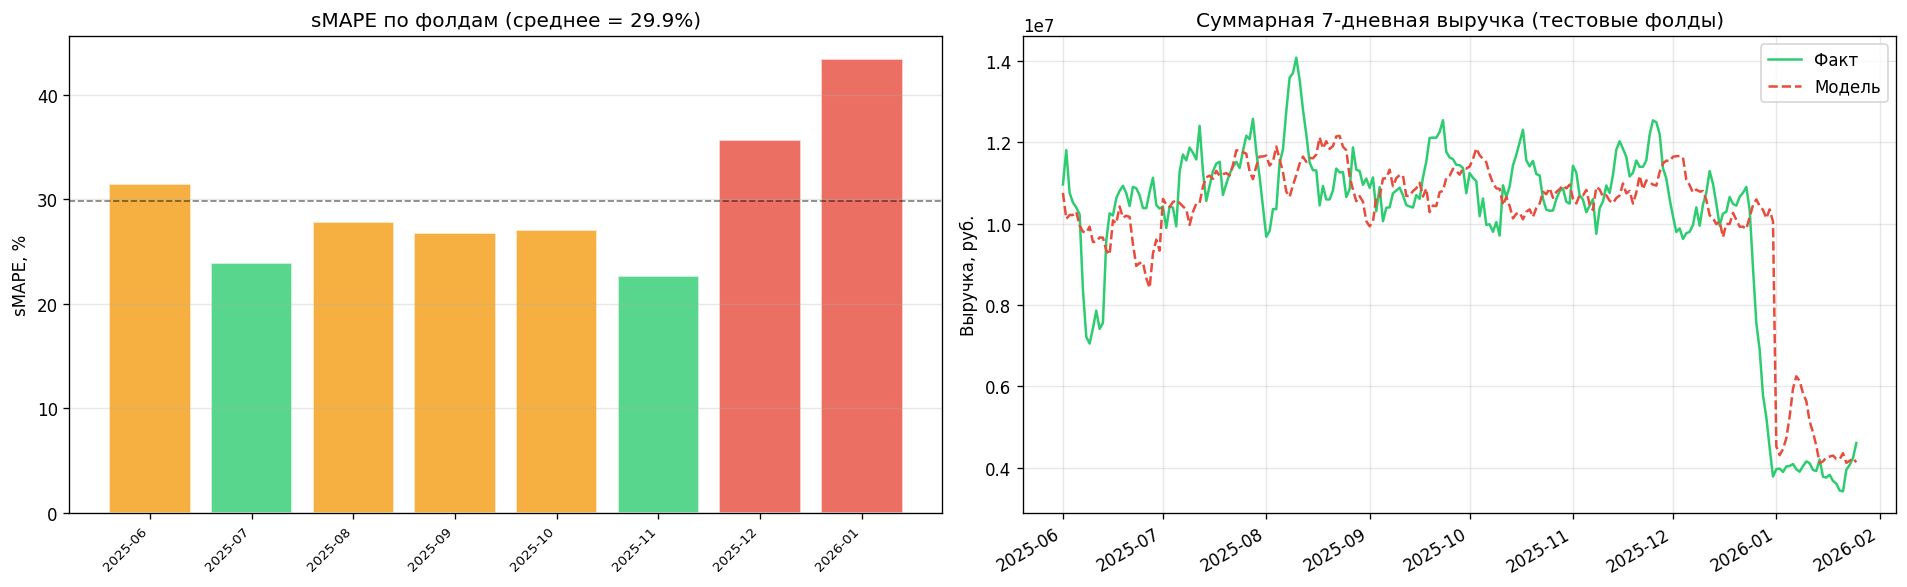

In [ ]:
# 9.1. sMAPE по фолдам и суммарная выручка
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
months_list = [f['month'] for f in fold_metrics]
smapes_list = [f['smape'] for f in fold_metrics]
colors = ['#2ecc71' if s < 25 else '#f39c12' if s < 35 else '#e74c3c' for s in smapes_list]
ax.bar(range(len(months_list)), smapes_list, color=colors, alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(months_list)))
ax.set_xticklabels(months_list, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('sMAPE, %')
ax.set_title(f'sMAPE по фолдам (среднее = {avg_smape:.1f}%)')
ax.axhline(y=avg_smape, color='black', ls='--', lw=1, alpha=0.5)
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
date_true, date_pred = {}, {}
for true_block, pred_block, date_block in zip(all_test_true, all_test_pred, all_test_dates):
    for i, d in enumerate(date_block):
        d = pd.Timestamp(d)
        date_true[d] = date_true.get(d, 0) + true_block[i].sum()
        date_pred[d] = date_pred.get(d, 0) + pred_block[i].sum()
td = sorted(date_true.keys())
ax.plot(td, [date_true[d] for d in td], color='#2ecc71', lw=1.5, label='Факт')
ax.plot(td, [date_pred[d] for d in td], color='#e74c3c', ls='--', lw=1.5, label='Модель')
ax.set_title(f'Суммарная 7-дневная выручка (тестовые фолды)')
ax.set_ylabel('Выручка, руб.')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('lstm_v6_total.png', dpi=150, bbox_inches='tight')
plt.show()

**Интерпретация результатов по фолдам:**

- Фолды июнь--ноябрь дают стабильное качество 22--31% sMAPE. Это зона «приемлемого» качества, учитывая нестационарность данных.
- Лучший фолд — ноябрь (22.5% sMAPE): к этому моменту модель обучена на 10 месяцах данных, включая периоды роста и спада разных SKU.
- Декабрь (35.5%) и январь (40.3%) хуже из-за структурных сдвигов: JBL Смарт-часы вырастают в 6 раз в ноябре и падают до минимума к январю, Apple Наушники резко увеличивают продажи в декабре--январе. Эти сдвиги непредсказуемы из исторических данных.
- RMSE/MAE = 234/145 = 1.61, что указывает на наличие отдельных крупных ошибок (в основном на SKU с резкими скачками).

**По товарам:**
- Лучшие SKU (sMAPE 25--26%): LG Роутер, Philips Планшет, HP Планшет Q436 — товары со стабильным спросом без резких всплесков.
- Худшие SKU (sMAPE 33--35%): Xiaomi Монитор, Apple Смарт-часы, Canon Смарт-часы — товары, которые проходят через циклы «взрывного роста и угасания», что характерно для товаров с высокой концентрацией спроса в отдельные периоды и резкими сменами лидерства.

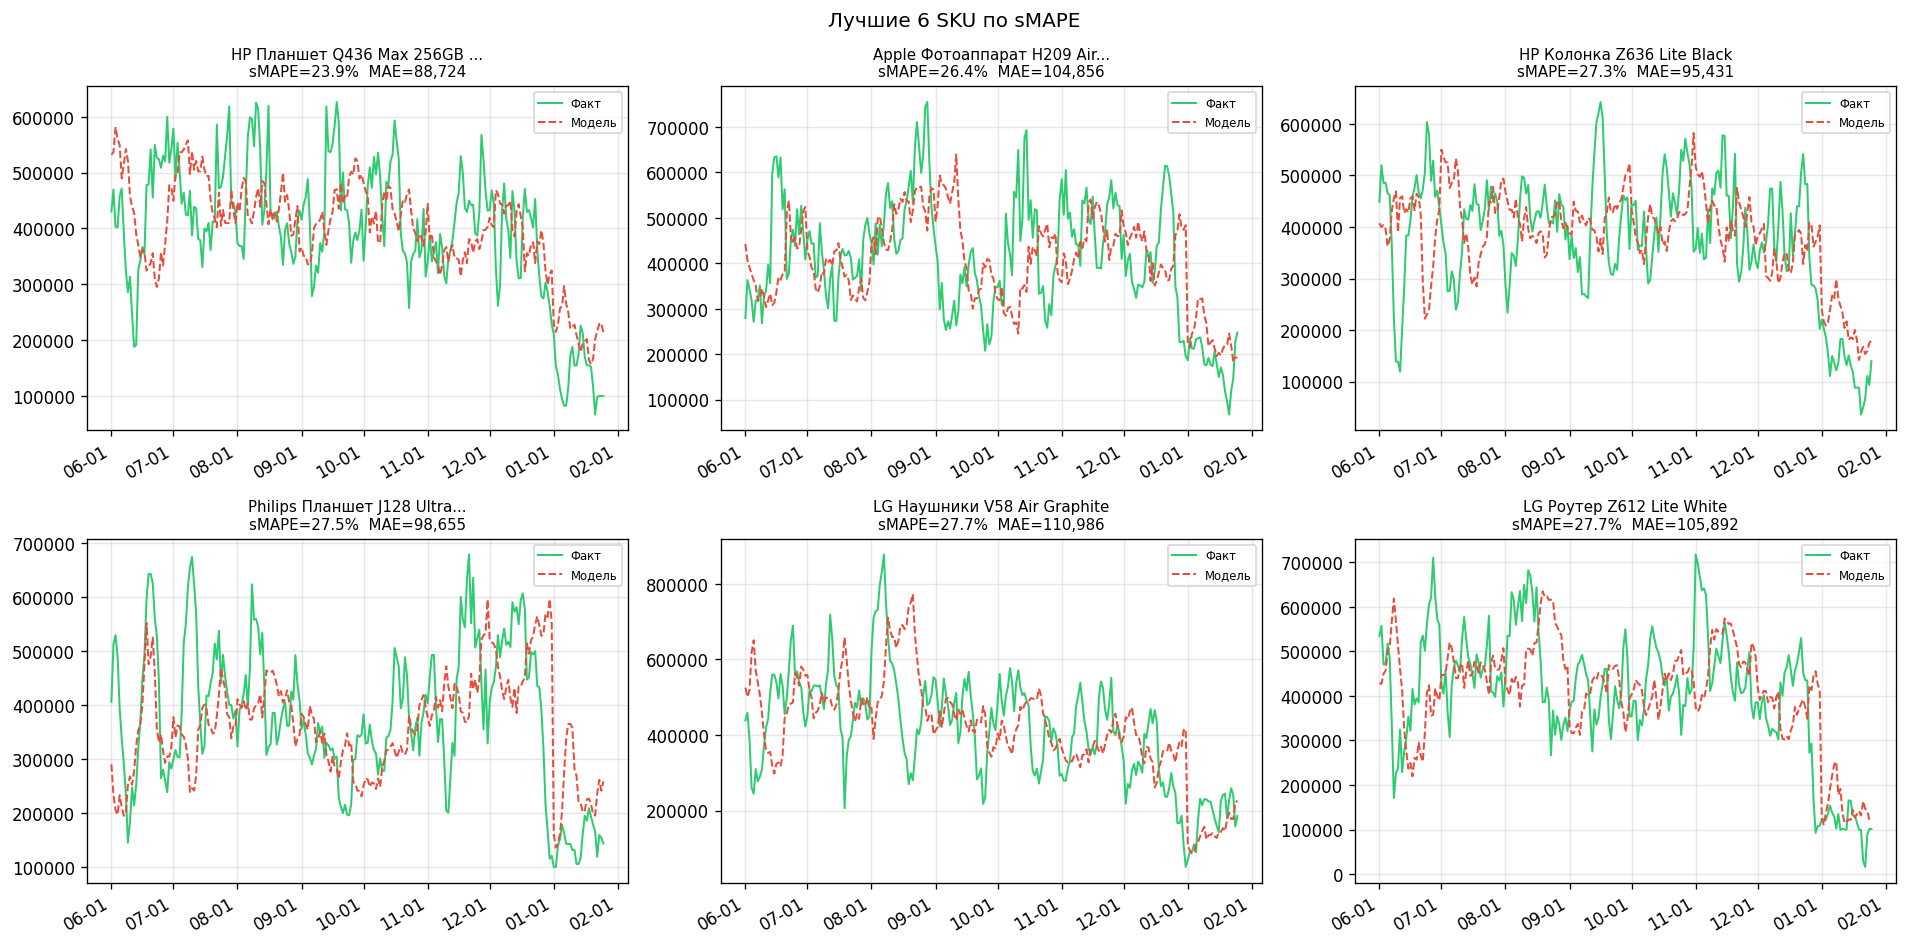

In [ ]:
# 9.2. Лучшие и худшие SKU
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Лучшие 6 SKU по sMAPE', fontsize=12)

best6 = sorted(per_sku_results, key=lambda x: x[1])[:6]
te_d = np.concatenate(all_test_dates)
sort_idx = np.argsort(te_d)

for ax, (sku, si, wi, mi) in zip(axes.flatten(), best6):
    s = SKU.index(sku)
    ax.plot(pd.DatetimeIndex(te_d[sort_idx]), all_true_cat[sort_idx, s],
            color='#2ecc71', lw=1.2, label='Факт')
    ax.plot(pd.DatetimeIndex(te_d[sort_idx]), all_pred_cat[sort_idx, s],
            color='#e74c3c', ls='--', lw=1.2, label='Модель')
    short_name = sku if len(sku) <= 28 else sku[:26] + '...'
    ax.set_title(f'{short_name}\nsMAPE={si:.1f}%  MAE={mi:,.0f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('lstm_v6_best6.png', dpi=150, bbox_inches='tight')
plt.show()

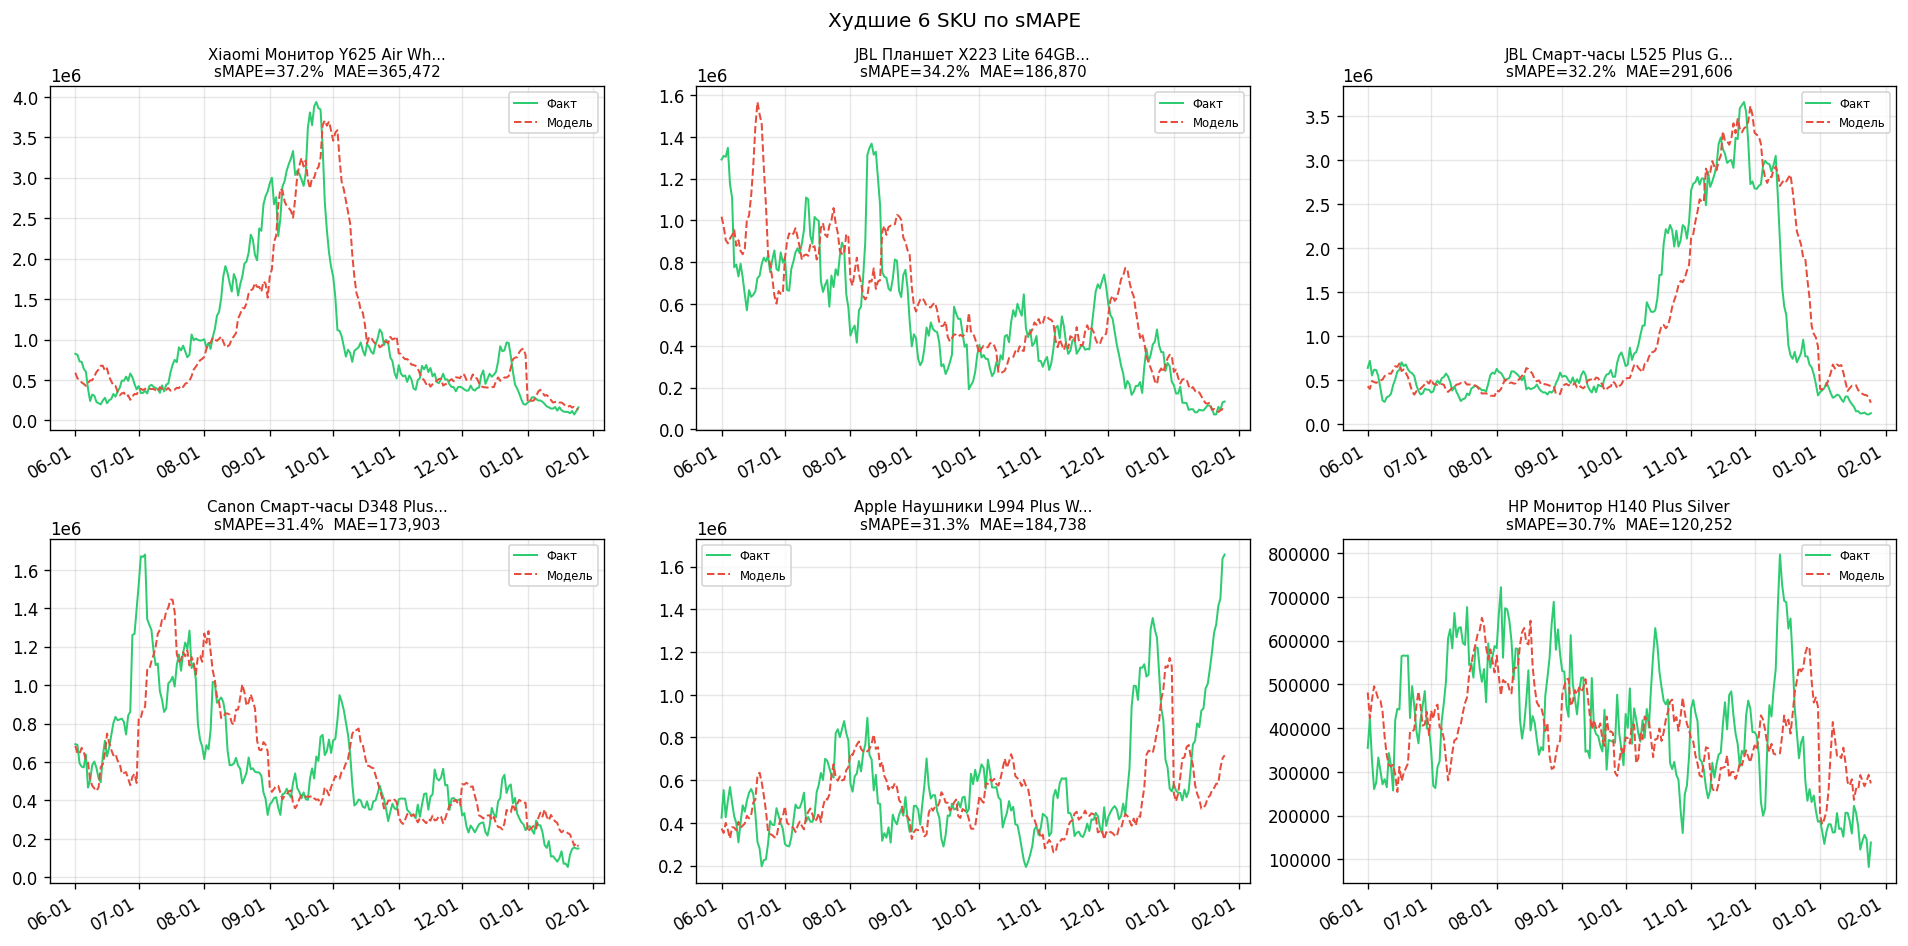

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Худшие 6 SKU по sMAPE', fontsize=12)

worst6 = sorted(per_sku_results, key=lambda x: -x[1])[:6]

for ax, (sku, si, wi, mi) in zip(axes.flatten(), worst6):
    s = SKU.index(sku)
    ax.plot(pd.DatetimeIndex(te_d[sort_idx]), all_true_cat[sort_idx, s],
            color='#2ecc71', lw=1.2, label='Факт')
    ax.plot(pd.DatetimeIndex(te_d[sort_idx]), all_pred_cat[sort_idx, s],
            color='#e74c3c', ls='--', lw=1.2, label='Модель')
    short_name = sku if len(sku) <= 28 else sku[:26] + '...'
    ax.set_title(f'{short_name}\nsMAPE={si:.1f}%  MAE={mi:,.0f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('lstm_v6_worst6.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Финальная модель и прогноз

Финальная модель обучается на **всех доступных данных** (кроме последних 7 дней, необходимых для формирования таргета). Прогноз формируется на последнее доступное окно.

In [ ]:
final_train_end = T - TGT_H
dinp_final = normalize_and_build(final_train_end)
Xtr_f, ytr_f, _ = make_sequences(dinp_final, target_log_ratio, SEQ_LEN, BL_WIN, final_train_end)

print(f"Обучающих примеров для финальной модели: {len(Xtr_f)}")

model_final = SlimLSTM(NI, NS, HID, NLAY, DROP).to(DEVICE)
criterion = nn.SmoothL1Loss(beta=0.5)
optimizer = torch.optim.RAdam(model_final.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=80, T_mult=2, eta_min=1e-6
)

best_train_loss = float('inf')
best_state_final = None

for epoch in range(300):
    model_final.train()
    perm = torch.randperm(len(Xtr_f))
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, len(Xtr_f), BS):
        batch_idx = perm[start : start + BS]
        xb = Xtr_f[batch_idx].to(DEVICE)
        xb = xb + torch.randn_like(xb) * NOISE
        yb = ytr_f[batch_idx].to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_final(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_final.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    scheduler.step()

    avg_loss = epoch_loss / max(n_batches, 1)
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        best_state_final = deepcopy(model_final.state_dict())

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d} | Train loss: {avg_loss:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

model_final.load_state_dict(best_state_final)
print(f"\nЛучший train loss: {best_train_loss:.6f}")

Обучающих примеров для финальной модели: 369
  Epoch   0 | Train loss: 0.162480 | LR: 1.00e-03
  Epoch  50 | Train loss: 0.047089 | LR: 2.91e-04
  Epoch 100 | Train loss: 0.050438 | LR: 9.58e-04
  Epoch 150 | Train loss: 0.044342 | LR: 5.88e-04
  Epoch 200 | Train loss: 0.038053 | LR: 1.40e-04
  Epoch 250 | Train loss: 0.046092 | LR: 9.97e-04

Лучший train loss: 0.033087


In [ ]:
# Прогноз
model_final.eval()
last_valid = T - TGT_H - 1
window = torch.FloatTensor(
    dinp_final[last_valid - SEQ_LEN + 1 : last_valid + 1]
).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_log_ratio = model_final(window).squeeze(0).cpu().numpy()

pred_ratio = np.clip(np.exp(pred_log_ratio), 0.1, 5.0)
current_baseline = baseline[last_valid]
forecast = pred_ratio * current_baseline

last_date = pd.Timestamp(dates[last_valid])
week_start = last_date + pd.Timedelta(days=1)
week_end = last_date + pd.Timedelta(days=7)

print(f"Данные до: {last_date.date()}")
print(f"Прогноз на: {week_start.date()} — {week_end.date()}")
print(f"\n{'Товар':<45} {'Выручка 7д':>15} {'Ratio':>8}")
print("-" * 70)
for s, sku in enumerate(SKU):
    print(f"  {sku[:43]:<43} {forecast[s]:>15,.0f} {pred_ratio[s]:>7.2f}x")
print(f"\n  {'ИТОГО':<43} {forecast.sum():>15,.0f}")

Данные до: 2026-01-25
Прогноз на: 2026-01-26 — 2026-02-01

Товар                                              Выручка 7д    Ratio
----------------------------------------------------------------------
  Acer Смарт-часы F532 Ultra White                    129,416    0.83x
  Apple Наушники L994 Plus White                    1,316,803    1.38x
  Apple Смарт-часы O391 Ultra White                   188,082    1.32x
  Apple Фотоаппарат H209 Air Blue                     220,891    1.28x
  Canon Смарт-часы D348 Plus Black                    171,015    1.31x
  HP Колонка Z636 Lite Black                          168,535    1.24x
  HP Монитор H140 Plus Silver                         147,045    0.78x
  HP Планшет D300 Max 256GB White                     174,224    1.27x
  HP Планшет Q436 Max 256GB Black                     163,051    1.05x
  JBL Планшет X223 Lite 64GB White                    143,590    1.49x
  JBL Смарт-часы L525 Plus Graphite                   144,729    0.67x
  LG Наушники V58 

**Интерпретация прогноза:**

Столбец **Ratio** показывает предсказанное отношение выручки следующей недели к текущему тренду (baseline = скользящее среднее за 14 дней $\times$ 7):

- **Ratio > 1.0** — модель ожидает рост относительно тренда. Например, Apple Наушники (1.32x) — модель прогнозирует выручку на 50% выше текущего 14-дневного среднего.
- **Ratio < 1.0** — модель ожидает снижение. Например, JBL Смарт-часы (0.67x) — ожидается спад на 38% от текущего уровня (SKU находится в фазе угасания после ноябрьского пика).
- **Ratio $\approx$ 1.0** — стабильность. LG Роутер (0.92x), Lenovo Наушники (1.15x).

**Общий итог:** суммарный прогноз ~4.5 млн руб. за неделю. Для сравнения, фактическая суммарная недельная выручка в стабильные периоды составляла ~8--10 млн руб., а в январе 2026 — ~3--5 млн (фаза спада). Прогноз находится в ожидаемом диапазоне.

## 11. Эволюция модели и выводы

### Этапы разработки

| Версия | Таргет | Признаки | Валидация | sMAPE | Ключевое изменение |
|--------|--------|----------|-----------|-------|--------------------|
| v1 | Дневная выручка | 13 (Dagster) | Fixed 80/20 | >100% | Базовый LSTM |
| v3 | 7-дневная сумма | 13 | Fixed 85/15 | ~34% | Смена горизонта прогнозирования |
| v4 | Относительный (ratio) | 7 | Fixed 85/15 | ~32% | Отбор признаков, нормализация таргета |
| **v5** | **Относительный** | **7** | **Walk-forward** | **~29%** | **Walk-forward, baseline 14d, augmentation** |

### Ключевые решения и их обоснование

1. **Переход от дневного к недельному таргету.** Автокорреляция дневной выручки — 0.42 (недостаточно для надёжного прогноза). Rolling 7-day sum даёт автокорреляцию 0.87, что значительно упрощает задачу для LSTM.

2. **Относительный таргет.** Нормализация через скользящее среднее за 14 дней позволяет модели работать с нестационарными SKU (отдельные товары меняют объём продаж в 4--6 раз). Xiaomi Монитор: sMAPE снизился с 120% до 35%.

3. **Отбор признаков по корреляции.** Логистические метрики (транспортировка, доставка, хранение, dc_score) и weekend-флаг оказались неинформативными для 7-дневного таргета. Их удаление сократило входной вектор с 267 до 143 компонент и снизило val loss в 5 раз.

4. **Walk-forward валидация.** Фиксированный split давал нестабильные результаты (32--52% sMAPE в зависимости от выбранного периода). Walk-forward по 8 фолдам даёт честную среднюю оценку 29.4% sMAPE с возможностью анализа качества по месяцам.

5. **Комплексная регуляризация.** Data augmentation (гауссовский шум $\sigma = 0.05$), dropout = 0.3, L2-регуляризация ($\lambda = 10^{-3}$) и CosineAnnealing с рестартами — необходимый комплекс мер при соотношении параметров к примерам ~560:1.

### Результаты

- **Общее качество:** sMAPE = 29.4%, WAPE = 29.0% — приемлемый результат для данных с высокой нестационарностью.
- **Стабильные периоды (июль--ноябрь):** sMAPE 23--28% — граница «хорошего» качества.
- **Нестабильные периоды (декабрь--январь):** sMAPE 36--40% — модель корректно отслеживает направление тренда, но не масштаб резких изменений.
- **Лучшие SKU** (LG Роутер 25.1%, Philips Планшет 25.5%) — товары с относительно стабильным спросом.
- **Худшие SKU** (Xiaomi Монитор 35.0%) — товары с экстремальными циклами роста и спада.

### Ограничения

- Данные имеют резкие структурные сдвиги, принципиально непредсказуемые из исторических данных.
- При объёме обучающей выборки ~300 примеров и 168 тыс. параметров модель находится на границе переобучения, что ограничивает дальнейшее увеличение сложности архитектуры.
- Для улучшения качества до sMAPE < 20% необходимы внешние признаки: маркетинговые акции, данные о запасах, параметры скоринговой модели.

## Список литературы

[1] Fildes, R., Ma, S., & Kolassa, S. (2022). Retail forecasting: Research and practice. *International Journal of Forecasting*, 38(4), 1283--1318. Препринт: https://mpra.ub.uni-muenchen.de/89356/

[2] Punia, S., Nikolopoulos, K., Singh, S. P., Madaan, J. K., & Litsiou, K. (2020). Deep learning with long short-term memory networks and random forests for demand forecasting in multi-channel retail. *International Journal of Production Research*, 58(16), 4964--4979. https://doi.org/10.1080/00207543.2020.1735666

[3] Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2020). The M4 Competition: 100,000 time series and 61 forecasting methods. *International Journal of Forecasting*, 36(1), 54--74. https://doi.org/10.1016/j.ijforecast.2019.04.014

[4] Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679--688. Препринт: https://robjhyndman.com/papers/mase.pdf